# Aula 2 - Estatística Descritiva & Pré-Processamento

## **Problema:** Impacto da Campanha de Marketing

Você é um analista de dados contratado por uma empresa de e-commerce chamada ShopEasy.

A empresa lançou recentemente uma campanha de marketing agressiva para aumentar suas vendas.

A campanha começou no início de julho de 2023 e durou até dezembro de 2023.

**Objetivo:**

Sua missão é avaliar o impacto da campanha de marketing e nas vendas da ShopEasy.

Para isso, você precisa analisar um conjunto de dados:

- Com observações de antes e depois da campanha de marketing.

**Perguntas a serem respondidas:**

1. Análise Descritiva
    - Qual foi a média de vendas antes e depois da campanha?
    - Qual foi a mediana da receita diária antes e depois da campanha?
    - Houve diferença no produto mais comprado antes e depois da campanha?
    - Como se distribuíram as vendas antes e depois da campanha?

2. Pré-processamento de dados
    - Há dados nulos? Se sim, o que fazer?
    - Há dados duplicados? O que eles nos dizem?
    - Como padronizar ou normalizar os meus dados?
    - Como faço para analisar a influência de uma variável categórica e a correlação dela com uma numérica?
    - Como faço para criar novas variáveis e melhorar minha capacidade analítica?

2. Comparação de Períodos
    - Há algum valor anômalo nas vendas antes e depois da campanha?
    - Há diferença na variação dos dados comparando os períodos de despesas antes e depois da campanha?
    - As despesas de marketing justificaram o aumento nas vendas e na receita?

## Tipos de Variáveis

Antes de partirmos para as nossas análises, precisamos entender o que é uma variável e quais são os tipos principais.

Quando coletamos informações, em geral, realizamos uma **amostragem** (tópico de outra aula).

Essas informações vão muito além do que números ou palavras, trazendo consigo características e contextos fundamentais para as nossas futuras análises e modelos.

Cada uma dessas características coletadas (peso, altura, idade, sexo) é chamada de **variável**.

As variáveis podem ser:

!['Imagem'](https://miro.medium.com/max/1400/0*rxxyee4xr8HD1O6N.png)

* **Discreta**: apenas valores inteiros (n° irmãos, filhos, passageiros);
* **Contínuas**: Qualquer valor no intervalo de n° reais (peso, altura, salário);
* **Nominais**: Categorias sem ordem (nome, sexo, cores);
* **Ordinais**: Categorias com ordem (tamanho: P, M, G; classe social: baixa, média, alta; grau de instrução: básico, fundamental, médio, superior).

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# desabilita os warnings
import warnings
import os 
warnings.filterwarnings('ignore')

In [9]:
current_path = os.getcwd()
df_campanha = pd.read_csv(current_path+"//Estudo_Clientes.csv")


In [10]:
df_campanha.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4380 entries, 0 to 4379
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Data                   4380 non-null   object 
 1   Vendas                 4380 non-null   float64
 2   Receita                4380 non-null   float64
 3   Despesas_de_Marketing  4380 non-null   float64
 4   Numero_de_Clientes     4380 non-null   int64  
 5   Canal_de_Venda         4380 non-null   object 
 6   Regiao                 4380 non-null   object 
 7   Produto                4380 non-null   object 
dtypes: float64(3), int64(1), object(4)
memory usage: 273.9+ KB


- 4 variáveis qualitativas (Data, Canal de Vendas, Produto e Região)
- 4 variáveis quantitativas (vendas, receitas, despesas de marketing, número de clientes)

## Análise Descritiva



### **Pergunta 1:** Qual foi a média de vendas antes e depois da campanha?

**Média (mean, average):** Demonstra a concentração dos dados de uma distribuição.

**Obs.:** É como se fosse o ponto de equilíbrio da distribuição e pode ser calculada por:

!['média'](https://miro.medium.com/max/628/1*U9LeYbNWJt0YERVo4KU61w.png)

In [11]:
#Ver as 5 primeiras linhas do DF
df_campanha.head()

,Data,Vendas,Receita,Despesas_de_Marketing,Numero_de_Clientes,Canal_de_Venda,Regiao,Produto
0,2023-01-01,12.215111,18.858133,0.321511,13,E-commerce,Centro-Oeste,Cosméticos
1,2023-01-01,6.215111,8.858133,4.321511,11,E-commerce,North,Livros
2,2023-01-01,6.215111,17.858133,4.321511,11,Mídia Social,North,Alimentos
3,2023-01-01,12.215111,14.858133,-2.678489,12,Mídia Social,East,Roupas
4,2023-01-01,9.215111,21.858133,0.321511,13,Loja Física,East,Eletrônicos


In [12]:
#Definir a data de início da campanha
data_inicio_campanha = "2023-07-01"
#Máscara para filtrar os dados antes da campanha
mascara_antes = (df_campanha["Data"] < data_inicio_campanha)
#Criar um dataframe para os dados antes da campanha
df_antes_campanha = df_campanha[mascara_antes]
#Máscara para filtrar os dados depois da campanha
mascara_depois = (df_campanha["Data"] >= data_inicio_campanha)
#Criar um dataframe para os dados depois da campanha
df_depois_campanha = df_campanha[mascara_depois]

In [13]:
df_depois_campanha.head()

,Data,Vendas,Receita,Despesas_de_Marketing,Numero_de_Clientes,Canal_de_Venda,Regiao,Produto
2172,2023-07-01,30.998843,11.198611,8.599884,1842,Mídia Social,South,Eletrônicos
2173,2023-07-01,33.998843,24.198611,15.599884,1841,E-commerce,East,Roupas
2174,2023-07-01,31.998843,33.198611,15.599884,1842,E-commerce,Centro-Oeste,Cosméticos
2175,2023-07-01,33.998843,35.198611,14.599884,1840,E-commerce,South,Cosméticos
2176,2023-07-01,34.998843,32.198611,11.599884,1840,Mídia Social,Centro-Oeste,Roupas


In [14]:
#Calcular as médias antes e depois da campanha
media_antes = df_antes_campanha["Vendas"].mean()
media_depois = df_depois_campanha["Vendas"].mean()

In [15]:
print(media_antes, media_depois)

15.706720076954369 33.57924285660438


### **Pergunta 2:** Qual foi a mediana da receita diária antes e depois da campanha?

**Mediana**: É o ponto médio, que divide os dados em 50% maiores e 50% maiores do que ele. É também conhecido como o 2°quartil (uma medida separatriz).
* Primeiro quartil (designado por $Q_{1}$) = quartil inferior = é o valor aos 25% da amostra ordenada = 25º percentil;
* Segundo quartil (designado por $Q_{2}$) = mediana = é o valor até ao qual se encontra 50% da amostra ordenada = 50º percentil, ou 5º decil;
* Terceiro quartil (designado por $Q_{3}$) = quartil superior = valor a partir do qual se encontram 25% dos valores mais elevados = valor aos 75% da amostra ordenada = 75º percentil.

In [16]:
#Calcular as medianas antes e depois da campanha
mediana_antes = df_antes_campanha["Receita"].median()
mediana_depois = df_depois_campanha["Receita"].median()

In [17]:
print(mediana_antes, mediana_depois)

12.633221296766196 34.548686491378874


### **Pergunta 3:** Houve diferença no produto mais comprado antes e depois da campanha?

**Moda:** Representa o(s) valores mais comuns dos dados:
* Unimodal: 1 único valor;
* Bimodal: 2 valores;
* Multimodal: Mais de 2 valores como os que mais aparecem;
* Amodal: Não existe moda.

In [18]:
df_antes_campanha["Produto"].mode()[0]

'Livros'

In [19]:
#Calcular as medianas antes e depois da campanha
df_moda_antes = df_antes_campanha["Produto"].mode()[0]
df_moda_depois = df_depois_campanha["Produto"].mode()[0]

In [20]:
print(df_moda_antes,df_moda_depois)

Livros Eletrônicos


### **Pergunta 4:** Como se distribuíram as vendas antes e depois da campanha?

In [21]:
import matplotlib.pyplot as plt

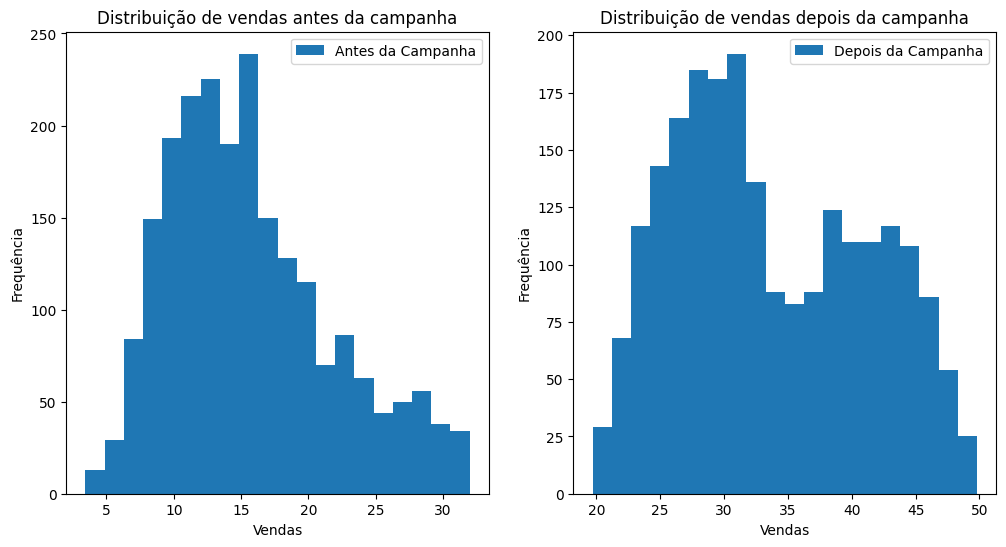

In [22]:
#Criando a distribuição antes da campanha
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(df_antes_campanha["Vendas"], bins = 20)
plt.title("Distribuição de vendas antes da campanha")
plt.xlabel("Vendas")
plt.ylabel("Frequência")
plt.legend(["Antes da Campanha"])

plt.subplot(1, 2, 2)
#Criando a distribuição depois da campanha
plt.hist(df_depois_campanha["Vendas"], bins = 20)
plt.title("Distribuição de vendas depois da campanha")
plt.xlabel("Vendas")
plt.ylabel("Frequência")
plt.legend(["Depois da Campanha"])
plt.show()

_____

#

## Pré-Processamento de dados:

### **Pergunta 5:** Existem valores nulos no DataFrame? Como tratá-los?

In [23]:
#Vendo se há valores nulos
df_antes_campanha.isnull().sum()

Data                     0
Vendas                   0
Receita                  0
Despesas_de_Marketing    0
Numero_de_Clientes       0
Canal_de_Venda           0
Regiao                   0
Produto                  0
dtype: int64

In [24]:
#Vendo se há valores nulos
df_depois_campanha.isna().mean()

Data                     0.0
Vendas                   0.0
Receita                  0.0
Despesas_de_Marketing    0.0
Numero_de_Clientes       0.0
Canal_de_Venda           0.0
Regiao                   0.0
Produto                  0.0
dtype: float64

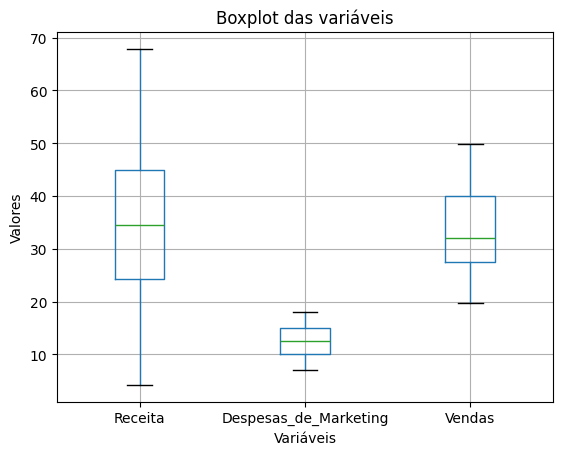

In [25]:
#Avaliar a distribuição dos dados em um boxplot
boxplot = df_depois_campanha.boxplot(column=['Receita','Despesas_de_Marketing','Vendas'])
plt.title('Boxplot das variáveis')
boxplot.set_ylabel('Valores')
boxplot.set_xlabel('Variáveis')
plt.show()

Como não há nenhum valor ausente, vamos criar alguns e depois ver como seria um tipo de tratamento.

In [26]:
import numpy as np

In [27]:
df_antes_campanha.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2172 entries, 0 to 2171
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Data                   2172 non-null   object 
 1   Vendas                 2172 non-null   float64
 2   Receita                2172 non-null   float64
 3   Despesas_de_Marketing  2172 non-null   float64
 4   Numero_de_Clientes     2172 non-null   int64  
 5   Canal_de_Venda         2172 non-null   object 
 6   Regiao                 2172 non-null   object 
 7   Produto                2172 non-null   object 
dtypes: float64(3), int64(1), object(4)
memory usage: 152.7+ KB


In [28]:
# Inserção de valores nulos distribuídos aleatoriamente pelas três colunas
for _ in range(len(df_antes_campanha)):
  row = np.random.randint(0, len(df_antes_campanha))
  col = np.random.choice(["Receita","Despesas_de_Marketing","Vendas"])
  df_antes_campanha.at[row, col] = np.nan

In [29]:
#Verificando a existência de NaN
df_antes_campanha.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2172 entries, 0 to 2171
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Data                   2172 non-null   object 
 1   Vendas                 1550 non-null   float64
 2   Receita                1570 non-null   float64
 3   Despesas_de_Marketing  1550 non-null   float64
 4   Numero_de_Clientes     2172 non-null   int64  
 5   Canal_de_Venda         2172 non-null   object 
 6   Regiao                 2172 non-null   object 
 7   Produto                2172 non-null   object 
dtypes: float64(3), int64(1), object(4)
memory usage: 217.3+ KB


**Estratégias para tratar os dados ausentes:**
- Remoção
- Substituição por valores estatísticos
- Substituição por valores fixos
- Forward fill e backward fill
- Modelos de machine learning

In [30]:
#Remoção de valores ausentes (linhas)
df_antes_campanha_2 = df_antes_campanha.copy()
df_antes_campanha_2.dropna(inplace=True)

In [31]:
df_antes_campanha_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 0 to 2170
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Data                   800 non-null    object 
 1   Vendas                 800 non-null    float64
 2   Receita                800 non-null    float64
 3   Despesas_de_Marketing  800 non-null    float64
 4   Numero_de_Clientes     800 non-null    int64  
 5   Canal_de_Venda         800 non-null    object 
 6   Regiao                 800 non-null    object 
 7   Produto                800 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 56.2+ KB


In [32]:
#Remoção de valores ausentes (colunas)
df_antes_campanha_2 = df_antes_campanha.copy()
df_antes_campanha_2.dropna(axis = 1, inplace=True)

In [33]:
df_antes_campanha_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2172 entries, 0 to 2171
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Data                2172 non-null   object
 1   Numero_de_Clientes  2172 non-null   int64 
 2   Canal_de_Venda      2172 non-null   object
 3   Regiao              2172 non-null   object
 4   Produto             2172 non-null   object
dtypes: int64(1), object(4)
memory usage: 166.4+ KB


In [34]:
#Substituir por valores estatísticos
df_antes_campanha_2 = df_antes_campanha.copy()
#Média
df_antes_campanha_2["Receita"].fillna(df_antes_campanha_2["Receita"].mean(),inplace = True)
#Mediana
df_antes_campanha_2["Vendas"].fillna(df_antes_campanha_2["Vendas"].median(),inplace = True)

In [35]:
df_antes_campanha_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2172 entries, 0 to 2171
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Data                   2172 non-null   object 
 1   Vendas                 2172 non-null   float64
 2   Receita                2172 non-null   float64
 3   Despesas_de_Marketing  1550 non-null   float64
 4   Numero_de_Clientes     2172 non-null   int64  
 5   Canal_de_Venda         2172 non-null   object 
 6   Regiao                 2172 non-null   object 
 7   Produto                2172 non-null   object 
dtypes: float64(3), int64(1), object(4)
memory usage: 217.3+ KB


**Obs.:** Geralmente a moda é para valores categóricos.

In [36]:
#Substituição com Valor Fixo
df_antes_campanha_2["Despesas_de_Marketing"].fillna(0,inplace = True)

In [37]:
df_antes_campanha_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2172 entries, 0 to 2171
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Data                   2172 non-null   object 
 1   Vendas                 2172 non-null   float64
 2   Receita                2172 non-null   float64
 3   Despesas_de_Marketing  2172 non-null   float64
 4   Numero_de_Clientes     2172 non-null   int64  
 5   Canal_de_Venda         2172 non-null   object 
 6   Regiao                 2172 non-null   object 
 7   Produto                2172 non-null   object 
dtypes: float64(3), int64(1), object(4)
memory usage: 217.3+ KB


In [38]:
#Substituir forward e backward fill
df_antes_campanha_2 = df_antes_campanha.copy()
df_antes_campanha_3 = df_antes_campanha.copy()

In [39]:
df_antes_campanha_2.isnull().sum()

Data                       0
Vendas                   622
Receita                  602
Despesas_de_Marketing    622
Numero_de_Clientes         0
Canal_de_Venda             0
Regiao                     0
Produto                    0
dtype: int64

In [40]:
df_antes_campanha_2.fillna(method='ffill')

,Data,Vendas,Receita,Despesas_de_Marketing,Numero_de_Clientes,Canal_de_Venda,Regiao,Produto
0,2023-01-01,12.215111,18.858133,0.321511,13,E-commerce,Centro-Oeste,Cosméticos
1,2023-01-01,6.215111,8.858133,0.321511,11,E-commerce,North,Livros
2,2023-01-01,6.215111,17.858133,0.321511,11,Mídia Social,North,Alimentos
3,2023-01-01,6.215111,14.858133,0.321511,12,Mídia Social,East,Roupas
4,2023-01-01,9.215111,21.858133,0.321511,13,Loja Física,East,Eletrônicos
...,...,...,...,...,...,...,...,...
2167,2023-06-30,22.989586,18.587503,3.298959,1814,Loja Física,Centro-Oeste,Alimentos
2168,2023-06-30,31.989586,16.587503,4.298959,1812,Mídia Social,East,Alimentos
2169,2023-06-30,22.989586,41.587503,-0.701041,1811,E-commerce,South,Alimentos
2170,2023-06-30,27.989586,26.587503,-2.701041,1810,Loja Física,East,Alimentos


In [41]:
df_antes_campanha_3.fillna(method='bfill')

,Data,Vendas,Receita,Despesas_de_Marketing,Numero_de_Clientes,Canal_de_Venda,Regiao,Produto
0,2023-01-01,12.215111,18.858133,0.321511,13,E-commerce,Centro-Oeste,Cosméticos
1,2023-01-01,6.215111,8.858133,0.321511,11,E-commerce,North,Livros
2,2023-01-01,6.215111,17.858133,0.321511,11,Mídia Social,North,Alimentos
3,2023-01-01,9.215111,14.858133,0.321511,12,Mídia Social,East,Roupas
4,2023-01-01,9.215111,21.858133,0.321511,13,Loja Física,East,Eletrônicos
...,...,...,...,...,...,...,...,...
2167,2023-06-30,22.989586,18.587503,4.298959,1814,Loja Física,Centro-Oeste,Alimentos
2168,2023-06-30,31.989586,16.587503,4.298959,1812,Mídia Social,East,Alimentos
2169,2023-06-30,22.989586,41.587503,-0.701041,1811,E-commerce,South,Alimentos
2170,2023-06-30,27.989586,26.587503,-2.701041,1810,Loja Física,East,Alimentos


Utilizando o simpleimputer

In [42]:
from sklearn.impute import SimpleImputer

In [43]:
df_antes_campanha_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2172 entries, 0 to 2171
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Data                   2172 non-null   object 
 1   Vendas                 1550 non-null   float64
 2   Receita                1570 non-null   float64
 3   Despesas_de_Marketing  1550 non-null   float64
 4   Numero_de_Clientes     2172 non-null   int64  
 5   Canal_de_Venda         2172 non-null   object 
 6   Regiao                 2172 non-null   object 
 7   Produto                2172 non-null   object 
dtypes: float64(3), int64(1), object(4)
memory usage: 217.3+ KB


In [44]:
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
df_antes_campanha_2[['Receita','Despesas_de_Marketing','Vendas']] = imputer.fit_transform(df_antes_campanha_2[['Receita','Despesas_de_Marketing','Vendas']])

In [45]:
df_antes_campanha_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2172 entries, 0 to 2171
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Data                   2172 non-null   object 
 1   Vendas                 2172 non-null   float64
 2   Receita                2172 non-null   float64
 3   Despesas_de_Marketing  2172 non-null   float64
 4   Numero_de_Clientes     2172 non-null   int64  
 5   Canal_de_Venda         2172 non-null   object 
 6   Regiao                 2172 non-null   object 
 7   Produto                2172 non-null   object 
dtypes: float64(3), int64(1), object(4)
memory usage: 217.3+ KB


### **Pergunta 6**: Há registros duplicados no DataFrame? Como removê-los?

In [46]:
# Inserindo uma linha duplicada (duplicando a linha com ID 1)
df = pd.concat([df_antes_campanha_2, df_antes_campanha_2.iloc[[1]]],ignore_index=True)

In [47]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2168    False
2169    False
2170    False
2171    False
2172     True
Length: 2173, dtype: bool

In [48]:
# Identificar os valores duplicados
duplicados = df[df.duplicated()]

In [49]:
duplicados

,Data,Vendas,Receita,Despesas_de_Marketing,Numero_de_Clientes,Canal_de_Venda,Regiao,Produto
2172,2023-01-01,6.215111,8.858133,0.535326,11,E-commerce,North,Livros


In [50]:
df = df.drop_duplicates()

In [51]:
df[df.duplicated()]

,Data,Vendas,Receita,Despesas_de_Marketing,Numero_de_Clientes,Canal_de_Venda,Regiao,Produto


### **Pergunta 7**: Como normalizar as despesas de marketing para a escala entre 0 e 1?

A transformação de dados tem como objetivo evitar que os algoritmos fiquem enviesados em virtude de variáveis com maiores ordens de grandeza.

- Normalização

$X_{norm} = \frac{X-X_{min}}{X_{max}-X_{min}}$

Tem como objetivo colocar as variáveis dentro do intervalo de 0 e 1.

- Padronização

$Z = \frac{X-\mu}{\sigma}$

**Obs.1:** A padronização resulta em uma média igual a zero e um desvio padrão igual a 1.

**Obs.2:** As duas técnicas têm como objetivo transformar todas as variáveis na mesma ordem de grandeza.

- Variáveis preditas e preditoras

In [52]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [53]:
df_antes_campanha_2 = df_antes_campanha.copy()
df_antes_campanha_3 = df_antes_campanha.copy()

In [54]:
# Obtém-se as colunas categóricas e numéricas:
colunas_categoricas = df_antes_campanha.select_dtypes('object').columns
colunas_numericas = df_antes_campanha.select_dtypes('number').columns

In [55]:
colunas_categoricas

Index(['Data', 'Canal_de_Venda', 'Regiao', 'Produto'], dtype='object')

In [56]:
colunas_numericas

Index(['Vendas', 'Receita', 'Despesas_de_Marketing', 'Numero_de_Clientes'], dtype='object')

In [57]:
scaler_1 = MinMaxScaler()
df_antes_campanha_2[colunas_numericas] = scaler_1.fit_transform(df_antes_campanha_2[colunas_numericas])

In [58]:
df_antes_campanha_2.head()

,Data,Vendas,Receita,Despesas_de_Marketing,Numero_de_Clientes,Canal_de_Venda,Regiao,Produto
0,2023-01-01,0.302385,0.551515,0.453345,0.001663,E-commerce,Centro-Oeste,Cosméticos
1,2023-01-01,0.090714,0.389195,NaN,0.000554,E-commerce,North,Livros
2,2023-01-01,0.090714,0.535283,NaN,0.000554,Mídia Social,North,Alimentos
3,2023-01-01,NaN,0.486587,NaN,0.001109,Mídia Social,East,Roupas
4,2023-01-01,0.196550,0.600211,0.453345,0.001663,Loja Física,East,Eletrônicos


In [59]:
scaler_1 = StandardScaler()
df_antes_campanha_3[colunas_numericas] = scaler_1.fit_transform(df_antes_campanha_3[colunas_numericas])

In [60]:
df_antes_campanha_3.head()

,Data,Vendas,Receita,Despesas_de_Marketing,Numero_de_Clientes,Canal_de_Venda,Regiao,Produto
0,2023-01-01,-0.573613,0.457097,-0.072623,-1.720584,E-commerce,Centro-Oeste,Cosméticos
1,2023-01-01,-1.551541,-0.318532,NaN,-1.724412,E-commerce,North,Livros
2,2023-01-01,-1.551541,0.379534,NaN,-1.724412,Mídia Social,North,Alimentos
3,2023-01-01,NaN,0.146845,NaN,-1.722498,Mídia Social,East,Roupas
4,2023-01-01,-1.062577,0.689785,-0.072623,-1.720584,Loja Física,East,Eletrônicos


### **Pergunta 8**: Como faço para analisar a influência de uma variável categórica e a correlação dela com uma numérica?

Ao trabalhar com variáveis categóricas como "canal_vendas", precisamos convertê-las em valores numéricos para que possam ser usadas em modelos de aprendizado de máquina. As duas abordagens mais comuns são:

1️⃣ Ordinal Encoding (OrdinalEncoder)

- Transforma categorias em números inteiros ordenados.
- Útil quando a variável tem uma ordem lógica (exemplo: Baixo (0), Médio (1), Alto (2)).
- Não deve ser usada para variáveis categóricas sem ordem natural, pois pode introduzir relações artificiais.

In [61]:
from sklearn.preprocessing import OrdinalEncoder

In [62]:
df_antes_campanha_2.head()

,Data,Vendas,Receita,Despesas_de_Marketing,Numero_de_Clientes,Canal_de_Venda,Regiao,Produto
0,2023-01-01,0.302385,0.551515,0.453345,0.001663,E-commerce,Centro-Oeste,Cosméticos
1,2023-01-01,0.090714,0.389195,NaN,0.000554,E-commerce,North,Livros
2,2023-01-01,0.090714,0.535283,NaN,0.000554,Mídia Social,North,Alimentos
3,2023-01-01,NaN,0.486587,NaN,0.001109,Mídia Social,East,Roupas
4,2023-01-01,0.196550,0.600211,0.453345,0.001663,Loja Física,East,Eletrônicos


In [63]:
ordinal = OrdinalEncoder()
df_antes_campanha_2[['Canal_de_Venda','Regiao','Produto']] = ordinal.fit_transform(df_antes_campanha_2[['Canal_de_Venda','Regiao','Produto']])

In [64]:
df_antes_campanha_2.head()

,Data,Vendas,Receita,Despesas_de_Marketing,Numero_de_Clientes,Canal_de_Venda,Regiao,Produto
0,2023-01-01,0.302385,0.551515,0.453345,0.001663,0.0,0.0,1.0
1,2023-01-01,0.090714,0.389195,NaN,0.000554,0.0,2.0,3.0
2,2023-01-01,0.090714,0.535283,NaN,0.000554,2.0,2.0,0.0
3,2023-01-01,NaN,0.486587,NaN,0.001109,2.0,1.0,4.0
4,2023-01-01,0.196550,0.600211,0.453345,0.001663,1.0,1.0,2.0


2️⃣ One-Hot Encoding (OneHotEncoder)

- Cria uma nova coluna binária (0 ou 1) para cada categoria.
- Útil quando não há ordem entre as categorias (exemplo: "Online", "Loja Física", "Parceiro").
- Pode aumentar muito o número de colunas se houver muitas categorias (problema da dimensionalidade).

In [ ]:
["Cor"
 "Azul",
 "Vermelho",
 "Preto"]

["Cor_Azul", "Cor_Vermelho", "Cor_Preto"
 1, 0, 0
 0, 1, 0
 0, 0, 1]

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1306506809.py, line 1)

In [ ]:
# Aplicando One-Hot Encoding
df_encoded = pd.get_dummies(df_antes_campanha_3, columns=['Canal_de_Venda','Regiao','Produto'])

In [ ]:
df_encoded

,Data,Vendas,Receita,Despesas_de_Marketing,Numero_de_Clientes,Canal_de_Venda_E-commerce,Canal_de_Venda_Loja Física,Canal_de_Venda_Mídia Social,Regiao_Centro-Oeste,Regiao_East,Regiao_North,Regiao_South,Produto_Alimentos,Produto_Cosméticos,Produto_Eletrônicos,Produto_Livros,Produto_Roupas
0,2023-01-01,NaN,0.477903,NaN,-1.720584,True,False,False,True,False,False,False,False,True,False,False,False
1,2023-01-01,NaN,-0.302450,NaN,-1.724412,True,False,False,False,False,True,False,False,False,False,True,False
2,2023-01-01,-1.536265,NaN,1.285984,-1.724412,False,False,True,False,False,True,False,True,False,False,False,False
3,2023-01-01,-0.578956,0.165762,-1.072202,-1.722498,False,False,True,False,True,False,False,False,False,False,False,True
4,2023-01-01,-1.057610,0.712008,-0.061551,-1.720584,False,True,False,False,True,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2167,2023-06-30,1.140129,0.456784,-0.742916,1.726324,False,True,False,True,False,False,False,True,False,False,False,False
2168,2023-06-30,2.576093,NaN,1.278387,1.722496,False,False,True,False,True,False,False,True,False,False,False,False
2169,2023-06-30,1.140129,2.251594,NaN,1.720582,True,False,False,False,False,False,True,True,False,False,False,False
2170,2023-06-30,1.937887,1.081066,-1.079800,1.718668,False,True,False,False,True,False,False,True,False,False,False,False


In [ ]:
# Inicializando o OneHotEncoder


In [ ]:
# Transformando os dados categóricos


In [ ]:
# Criando um novo DataFrame com os valores transformados


In [ ]:
# Concatenando os dados transformados ao DataFrame original (removendo as colunas originais)


**Desafio:** Aplicar o OnehotEncoder em casa.

### **Pergunta 9:** Como faço para criar novas variáveis e melhorar minha capacidade analítica?

#### Feature Engineering:
- Criação de novas variáveis
- Seleção de features

In [ ]:
# Convertendo a coluna 'Data' para datetime


In [ ]:
# Adicionar uma coluna com o dia da semana


In [ ]:
# Criar a coluna "Tipo_dia"


_____

## Comparação de Períodos

### **Pergunta 10**: Há algum valor anômalo nas vendas antes e depois da campanha?

*Outlier* são dados diferentes dos outros pontos que podem causar problemas em procedimentos estatísticos (mudar uma média).

**Exemplo:** Mudar uma idade e ver a média.

* Solução 1: Ordenar os dados para encontrar outliers;
* Solução 2: Utilizar gráficos: dispersão, boxplot;
* Solução 3: Utilizar IQR para encontrar;
* Solução 4: Utilizar o Z-score.

#### Solução 1

In [ ]:
#Criar o dataframe antes da campanha


#### Solução 2

#### Solução 3

$ IQR = Q_{3} - Q_{1} $

$Lim_{sup} = 1.5*IQR + Q_{3} $

$Lim_{inf} = Q_{1} - 1.5*IQR$

Calcular o IQR, o Lim_sup e o Lim_inf.

- Filtrar tudo o que está acima do lim_sup
- Filtrar tudo o que está abaixo do lim_inf

**Obs.:** Fazer isso para os dados antes e depois da campanha.

In [ ]:
#antes da campanha


#### Solução 4

**Teste z-score**

![](https://study.com/cimages/videopreview/videopreview-full/screenshot-234_121691.jpg)

$ Z = \frac{X - \mu}{\sigma}$

### **Pergunta 11:** Há diferença na variação dos dados comparando os períodos de despesas antes e depois da campanha?

#### Métricas de Dispersão
- Amplitude
- Variância
- Desvio padrão
- Coeficiente de variação

**Amplitude**: A diferença entre o maior e o menor valor de um conjunto de dados.

In [ ]:
#Calculando a amplitude


**Variância:** Mede o quanto os dados estão dispersos com relação à média. É calculada da seguinte forma:

!['Variância'](https://miro.medium.com/max/996/1*7BEyGiM3JHEEmU2XTB1zZA.png)

**Desvio-padrão**: mais utilizado por estar na unidade dos dados. É a raiz quadrada da variância.

!['Desvio-padrão'](https://miro.medium.com/max/1152/1*qPMBPNKhZvuPIBN1BQLV7w.png)

**Coeficiente de variação:** Variabilidade dos dados em relação à média.

**Desvio-padrão** é menor (CV<100%) ou maior (CV>100%) do que a média.

<img src="https://pt-static.z-dn.net/files/da8/c9fa1b423b0d680b0ef3308a49546de6.jpg" width="600">

### **Pergunta 7:** As despesas de marketing justificaram o aumento nas vendas e na receita?